In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use('default')

pd.set_option('display.max_columns', None)

In [4]:
fund_master = pd.read_csv("D:\\BlueStock FineTech\\data\\processed\\fund_master_clean.csv")

nav_history = pd.read_csv("D:\\BlueStock FineTech\\data\\processed\\nav_history_clean.csv")

aum = pd.read_csv("D:\\BlueStock FineTech\\data\\processed\\aum_by_fund_house_clean.csv")

sip = pd.read_csv("D:\\BlueStock FineTech\\data\\processed\\monthly_sip_inflows_clean.csv")

category = pd.read_csv("D:\\BlueStock FineTech\\data\\processed\\category_inflows_clean.csv")

folio = pd.read_csv("D:\\BlueStock FineTech\\data\\processed\\industry_folio_count_clean.csv")

performance = pd.read_csv("D:\\BlueStock FineTech\\data\\processed\\scheme_performance_clean.csv")

investor_transactions = pd.read_csv("D:\\BlueStock FineTech\\data\\processed\\investor_transactions_clean.csv")

portfolio = pd.read_csv("D:\\BlueStock FineTech\\data\\processed\\portfolio_holdings_clean.csv")

benchmark = pd.read_csv("D:\\BlueStock FineTech\\data\\processed\\benchmark_indices_clean.csv")

# Section A
# Daily Returns Calculation & Validation

In [6]:
# Create Daily Data
# Sort data

nav_history = nav_history.sort_values(
    ['amfi_code','date']
)

# Daily return calculation

nav_history['daily_return'] = (
    nav_history
    .groupby('amfi_code')['nav']
    .pct_change()
)

nav_history.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [7]:
daily_return_summary = (
    nav_history
    .groupby('amfi_code')['daily_return']
    .agg(
        mean_return='mean',
        volatility='std',
        min_return='min',
        max_return='max'
    )
    .reset_index()
)

daily_return_summary.head()

,amfi_code,mean_return,volatility,min_return,max_return
0,100016,0.000142,0.009164,-0.024744,0.032145
1,100025,0.000170,0.002460,-0.008188,0.008837
2,100033,0.001080,0.011929,-0.044238,0.041954
3,101206,0.000852,0.009177,-0.038121,0.033956
4,101207,0.000424,0.016251,-0.051847,0.054851


In [8]:
# Validation
nav_history['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [9]:
nav_history['daily_return'].isnull().sum()

np.int64(40)

In [10]:
print("Missing Returns:", nav_history['daily_return'].isnull().sum())

daily_return_summary.head()

Missing Returns: 40


,amfi_code,mean_return,volatility,min_return,max_return
0,100016,0.000142,0.009164,-0.024744,0.032145
1,100025,0.000170,0.002460,-0.008188,0.008837
2,100033,0.001080,0.011929,-0.044238,0.041954
3,101206,0.000852,0.009177,-0.038121,0.033956
4,101207,0.000424,0.016251,-0.051847,0.054851


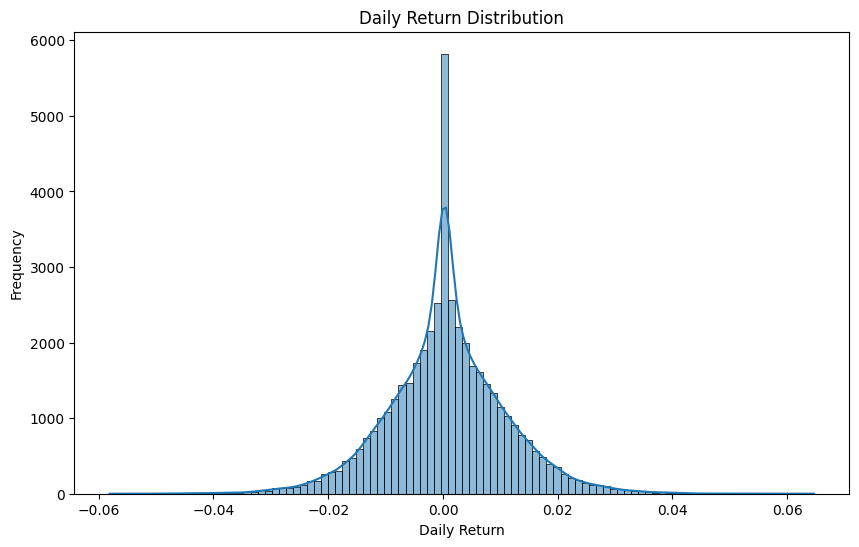

Chart Saved Successfully


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(
    nav_history['daily_return'].dropna(),
    bins=100,
    kde=True
)

plt.title('Daily Return Distribution')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.savefig(
    r"D:\BlueStock FineTech\dashboard\charts\daily_return_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Chart Saved Successfully")

In [57]:
daily_return_summary.to_csv(
    r"D:\BlueStock FineTech\data\processed\daily_return_summary.csv",
    index=False
)

# Section B
# CAGR Analysis (1Y, 3Y, 5Y)

In [12]:
# Prepare Datasets
nav_history['date'] = pd.to_datetime(nav_history['date'])

latest_date = nav_history['date'].max()

print("Latest Date:", latest_date)

Latest Date: 2026-05-29 00:00:00


In [13]:
# CAGR Function
def calculate_cagr(nav_df, years):

    results = []

    latest_date = nav_df['date'].max()

    start_date = latest_date - pd.DateOffset(years=years)

    for fund in nav_df['amfi_code'].unique():

        temp = nav_df[
            nav_df['amfi_code'] == fund
        ].sort_values('date')

        start_rows = temp[
            temp['date'] >= start_date
        ]

        if len(start_rows) == 0:
            continue

        start_nav = start_rows.iloc[0]['nav']
        end_nav = temp.iloc[-1]['nav']

        cagr = (
            (end_nav / start_nav) ** (1 / years)
        ) - 1

        results.append(
            [fund, cagr]
        )

    return pd.DataFrame(
        results,
        columns=['amfi_code', f'cagr_{years}yr']
    )

In [14]:
# Calculate All CAGR Matrics
cagr_1 = calculate_cagr(nav_history, 1)

cagr_3 = calculate_cagr(nav_history, 3)

cagr_5 = calculate_cagr(nav_history, 5)

In [15]:
# Merge Results
cagr_comparison = (
    cagr_1
    .merge(cagr_3, on='amfi_code')
    .merge(cagr_5, on='amfi_code')
)

cagr_comparison.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [16]:
# Convert to Percentage
cagr_cols = [
    'cagr_1yr',
    'cagr_3yr',
    'cagr_5yr'
]

cagr_comparison[cagr_cols] = (
    cagr_comparison[cagr_cols] * 100
)

cagr_comparison.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-2.224271,1.292649,2.316843
1,100025,3.704969,3.916390,3.912653
2,100033,53.232396,32.442459,26.074068
3,101206,47.924120,28.967695,20.442730
4,101207,-23.986032,-4.152381,6.953336


In [17]:
# Rank Fund By 3Y CAGR
cagr_comparison = (
    cagr_comparison
    .sort_values(
        'cagr_3yr',
        ascending=False
    )
)

cagr_comparison.head(10)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
16,119094,22.261065,35.111802,24.445309
34,148567,20.360678,34.000916,26.799277
24,120504,13.064279,32.487429,20.234028
2,100033,53.232396,32.442459,26.074068
25,120505,29.604659,31.777537,28.376762
19,119551,60.437341,30.456524,22.384873
30,120843,26.657082,29.582770,26.742494
36,148569,39.751761,29.178902,27.629860
3,101206,47.924120,28.967695,20.442730
39,149324,65.138719,27.000427,27.917430


In [18]:
# Export
cagr_comparison.to_csv(
    r"D:\BlueStock FineTech\data\processed\cagr_comparison.csv",
    index=False
)

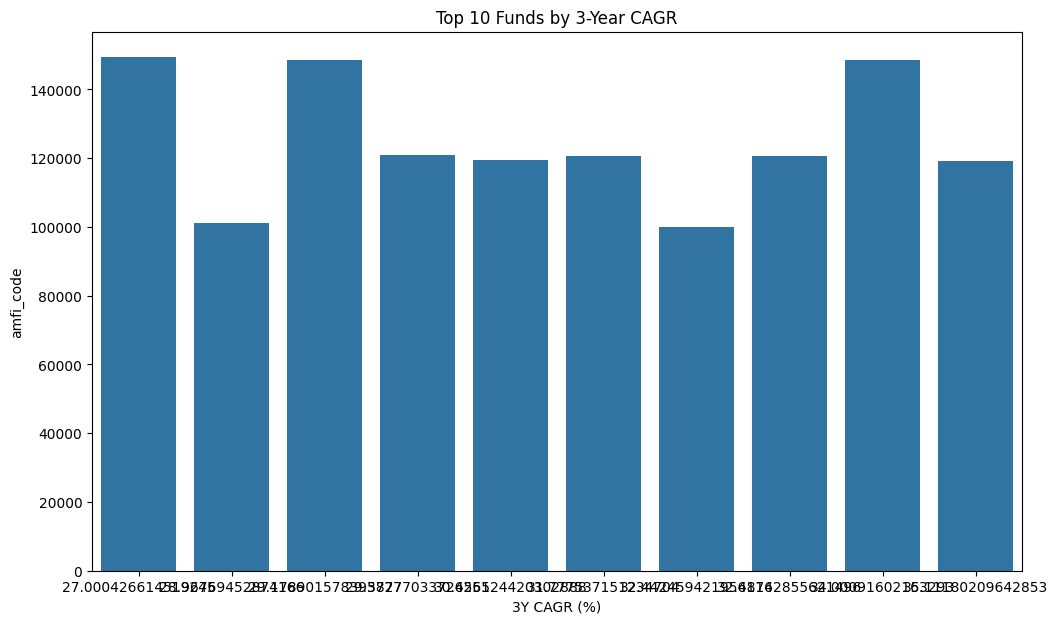

In [19]:
# Data Visualiztion
import matplotlib.pyplot as plt
import seaborn as sns

top10 = cagr_comparison.head(10)

plt.figure(figsize=(12,7))

sns.barplot(
    data=top10,
    x='cagr_3yr',
    y='amfi_code'
)

plt.title(
    'Top 10 Funds by 3-Year CAGR'
)

plt.xlabel('3Y CAGR (%)')

plt.savefig(
    r"D:\BlueStock FineTech\dashboard\charts\top10_cagr.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

The top-performing schemes generated significantly higher 3-year CAGR compared to category averages, highlighting strong long-term wealth creation potential.

In [20]:
print(cagr_comparison.shape)

cagr_comparison.head()

(40, 4)


,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
16,119094,22.261065,35.111802,24.445309
34,148567,20.360678,34.000916,26.799277
24,120504,13.064279,32.487429,20.234028
2,100033,53.232396,32.442459,26.074068
25,120505,29.604659,31.777537,28.376762


# Section C
# Sharpe Ratio Analysis

In [21]:
# Risk Free Rate
risk_free_rate = 0.065

daily_rf = risk_free_rate / 252

In [22]:
# Sharp Calculation
sharpe_results = []

for fund in nav_history['amfi_code'].unique():

    temp = nav_history[
        nav_history['amfi_code'] == fund
    ]

    returns = temp['daily_return'].dropna()

    mean_return = returns.mean()

    volatility = returns.std()

    sharpe = (
        (mean_return - daily_rf)
        /
        volatility
    ) * np.sqrt(252)

    sharpe_results.append(
        [fund, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        'amfi_code',
        'sharpe_ratio'
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [23]:
# Ranking
sharpe_df = (
    sharpe_df
    .sort_values(
        'sharpe_ratio',
        ascending=False
    )
)

sharpe_df.head(10)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [24]:
# Export
sharpe_df.to_csv(
    r"D:\BlueStock FineTech\data\processed\sharpe_ratio.csv",
    index=False
)

# Section D
# Sortino Ratio

In [25]:
# Sortino Calculation
sortino_results = []

for fund in nav_history['amfi_code'].unique():

    temp = nav_history[
        nav_history['amfi_code'] == fund
    ]

    returns = temp['daily_return'].dropna()

    downside_returns = returns[
        returns < 0
    ]

    downside_std = downside_returns.std()

    mean_return = returns.mean()

    sortino = (
        (mean_return - daily_rf)
        /
        downside_std
    ) * np.sqrt(252)

    sortino_results.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        'amfi_code',
        'sortino_ratio'
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [26]:
sortino_df.to_csv(
    r"D:\BlueStock FineTech\data\processed\sortino_ratio.csv",
    index=False
)

In [27]:
# Combined Ranking
risk_metrics = (
    sharpe_df
    .merge(
        sortino_df,
        on='amfi_code'
    )
)

risk_metrics.head()

,amfi_code,sharpe_ratio,sortino_ratio
0,148567,1.448291,2.385644
1,120843,1.306744,2.364320
2,148569,1.234930,2.146914
3,119551,1.208267,2.140267
4,120505,1.180101,2.029353


In [28]:
# Export
risk_metrics.to_csv(
    r"D:\BlueStock FineTech\data\processed\risk_metrics.csv",
    index=False
)

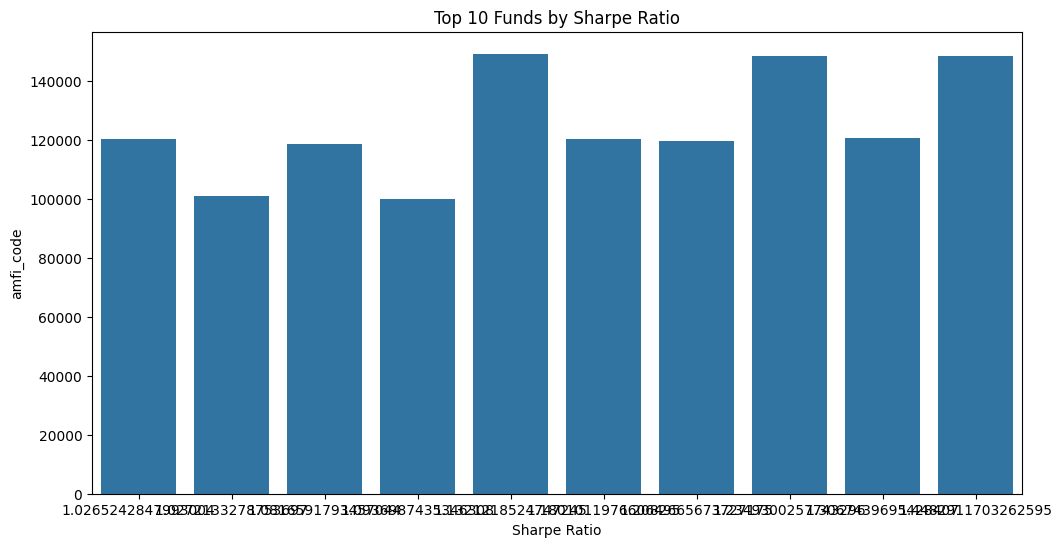

In [29]:
top10_sharpe = sharpe_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_sharpe,
    x='sharpe_ratio',
    y='amfi_code'
)

plt.title(
    'Top 10 Funds by Sharpe Ratio'
)

plt.xlabel('Sharpe Ratio')

plt.savefig(
    r"D:\BlueStock FineTech\dashboard\charts\top10_sharpe_ratio.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Funds with higher Sharpe ratios generated superior risk-adjusted returns, delivering better performance per unit of volatility.

In [30]:
sharpe_df.head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [31]:
sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [32]:
risk_metrics.head()

,amfi_code,sharpe_ratio,sortino_ratio
0,148567,1.448291,2.385644
1,120843,1.306744,2.364320
2,148569,1.234930,2.146914
3,119551,1.208267,2.140267
4,120505,1.180101,2.029353


# Section E
# Alpha & Beta (NIFTY100 Benchmark)

In [33]:
# NIFTY100 Data Prepare
from scipy.stats import linregress

benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty100 = nifty100.sort_values('date')

nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [34]:
# Alpha Beta Calculation
alpha_beta_results = []

for fund in nav_history['amfi_code'].unique():

    fund_df = nav_history[
        nav_history['amfi_code'] == fund
    ][['date','daily_return']]

    merged = pd.merge(
        fund_df,
        nifty100[['date','benchmark_return']],
        on='date',
        how='inner'
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        merged['benchmark_return'],
        merged['daily_return']
    )

    beta = slope

    alpha = intercept * 252

    alpha_beta_results.append(
        [fund, alpha, beta, r_value**2]
    )

In [35]:
# Create Data Frame
alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        'amfi_code',
        'alpha',
        'beta',
        'r_squared'
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta,r_squared
0,100016,0.037476,-0.058268,0.002665
1,100025,0.042818,0.001158,0.000015
2,100033,0.271954,0.005104,0.000012
3,101206,0.213998,0.021086,0.000348
4,101207,0.108971,-0.065289,0.001064


In [36]:
# Rank By Alpha
alpha_beta_df = (
    alpha_beta_df
    .sort_values(
        'alpha',
        ascending=False
    )
)

alpha_beta_df.head(10)

,amfi_code,alpha,beta,r_squared
21,119598,0.303370,-0.023196,1.414258e-04
39,149324,0.300579,0.011455,3.532991e-05
25,120505,0.292636,0.000549,1.345534e-07
36,148569,0.282704,0.018134,1.748889e-04
30,120843,0.273305,-0.022830,3.430543e-04
2,100033,0.271954,0.005104,1.206652e-05
34,148567,0.269838,0.023684,4.625437e-04
38,149323,0.265986,-0.002523,3.357978e-06
16,119094,0.260767,-0.066265,1.936879e-03
19,119551,0.232010,-0.031751,8.869789e-04


In [37]:
# Export
alpha_beta_df.to_csv(
    r"D:\BlueStock FineTech\data\processed\alpha_beta.csv",
    index=False
)

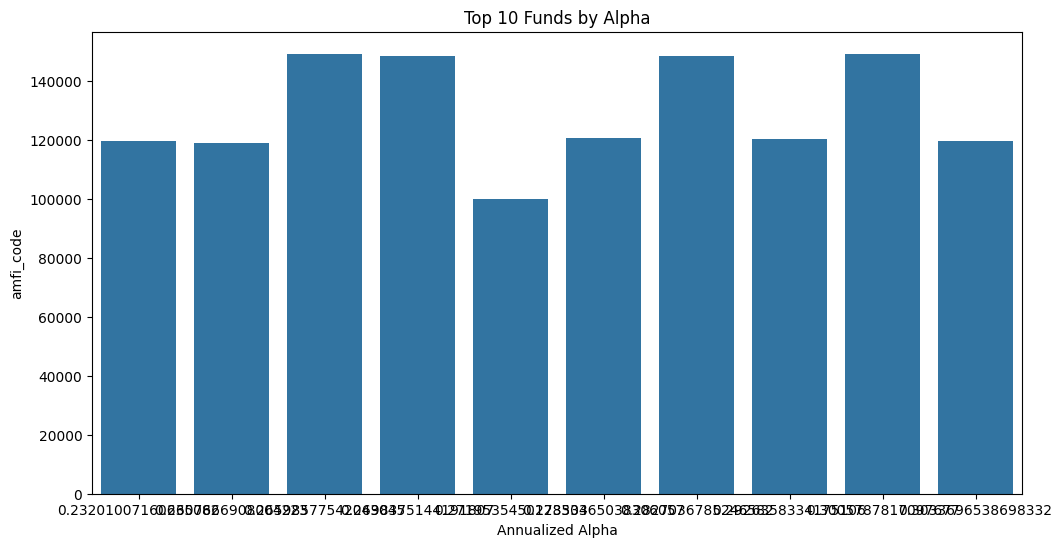

In [38]:
# Visualization
top10_alpha = alpha_beta_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_alpha,
    x='alpha',
    y='amfi_code'
)

plt.title(
    'Top 10 Funds by Alpha'
)

plt.xlabel('Annualized Alpha')

plt.savefig(
    r"D:\BlueStock FineTech\dashboard\charts\top10_alpha.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Funds with positive alpha consistently outperformed the NIFTY100 benchmark after adjusting for market risk.

In [39]:
print(alpha_beta_df.shape)

alpha_beta_df.head()

(40, 4)


,amfi_code,alpha,beta,r_squared
21,119598,0.303370,-0.023196,1.414258e-04
39,149324,0.300579,0.011455,3.532991e-05
25,120505,0.292636,0.000549,1.345534e-07
36,148569,0.282704,0.018134,1.748889e-04
30,120843,0.273305,-0.022830,3.430543e-04


# Section F
# Maximum Drawdown Analysis

In [43]:
 # Calculate Max Drawdown
max_dd_results = []

for fund in nav_history['amfi_code'].unique():

    temp = (
        nav_history[
            nav_history['amfi_code'] == fund
        ]
        .sort_values('date')
        .copy()
    )

    temp['running_max'] = temp['nav'].cummax()

    temp['drawdown'] = (
        temp['nav']
        /
        temp['running_max']
        - 1
    )

    worst_row = temp.loc[
        temp['drawdown'].idxmin()
    ]

    max_dd_results.append([
        fund,
        worst_row['drawdown'],
        worst_row['date']
    ])

In [41]:
# Create DataFrame
max_dd_df = pd.DataFrame(
    max_dd_results,
    columns=[
        'amfi_code',
        'max_drawdown',
        'worst_date'
    ]
)

max_dd_df.head()

,amfi_code,max_drawdown,worst_date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [42]:
# Export
max_dd_df.to_csv(
    r"D:\BlueStock FineTech\data\processed\max_drawdown.csv",
    index=False
)

# Section G
# Fund Scorecard(0-100)

In [45]:
# Load Expense Ratio
expense_df = performance[
    ['amfi_code','expense_ratio_pct']
].copy()

In [46]:
# Merge Matrix
scorecard = (
    cagr_comparison[['amfi_code','cagr_3yr']]
    .merge(
        sharpe_df,
        on='amfi_code'
    )
    .merge(
        alpha_beta_df[['amfi_code','alpha']],
        on='amfi_code'
    )
    .merge(
        expense_df,
        on='amfi_code'
    )
    .merge(
        max_dd_df[['amfi_code','max_drawdown']],
        on='amfi_code'
    )
)

scorecard.head()

,amfi_code,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown
0,119094,35.111802,0.998231,0.260767,1.38,-0.209609
1,148567,34.000916,1.448291,0.269838,1.46,-0.112657
2,120504,32.487429,1.026524,0.211948,0.80,-0.125883
3,100033,32.442459,1.093699,0.271954,1.38,-0.162172
4,120505,31.777537,1.180101,0.292636,1.36,-0.181885


In [47]:
# Ranking
scorecard['return_rank'] = (
    scorecard['cagr_3yr']
    .rank(pct=True)
)

scorecard['sharpe_rank'] = (
    scorecard['sharpe_ratio']
    .rank(pct=True)
)

scorecard['alpha_rank'] = (
    scorecard['alpha']
    .rank(pct=True)
)

scorecard['expense_rank'] = (
    (-scorecard['expense_ratio_pct'])
    .rank(pct=True)
)

scorecard['drawdown_rank'] = (
    (-scorecard['max_drawdown'])
    .rank(pct=True)
)

In [48]:
# final Score
scorecard['fund_score'] = (

      scorecard['return_rank'] * 30

    + scorecard['sharpe_rank'] * 25

    + scorecard['alpha_rank'] * 20

    + scorecard['expense_rank'] * 15

    + scorecard['drawdown_rank'] * 10

)

scorecard['fund_score'] = (
    scorecard['fund_score']
    .round(2)
)

scorecard.head()

,amfi_code,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
0,119094,35.111802,0.998231,0.260767,1.38,-0.209609,1.000,0.750,0.800,0.600,0.700,80.75
1,148567,34.000916,1.448291,0.269838,1.46,-0.112657,0.975,1.000,0.850,0.450,0.200,80.00
2,120504,32.487429,1.026524,0.211948,0.80,-0.125883,0.950,0.775,0.700,0.725,0.300,75.75
3,100033,32.442459,1.093699,0.271954,1.38,-0.162172,0.925,0.850,0.875,0.600,0.500,80.50
4,120505,31.777537,1.180101,0.292636,1.36,-0.181885,0.900,0.900,0.950,0.650,0.625,84.50


In [49]:
# Sort
scorecard = (
    scorecard
    .sort_values(
        'fund_score',
        ascending=False
    )
)

scorecard.head(10)

,amfi_code,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
4,120505,31.777537,1.180101,0.292636,1.36,-0.181885,0.900,0.900,0.950,0.6500,0.625,84.50
0,119094,35.111802,0.998231,0.260767,1.38,-0.209609,1.000,0.750,0.800,0.6000,0.700,80.75
3,100033,32.442459,1.093699,0.271954,1.38,-0.162172,0.925,0.850,0.875,0.6000,0.500,80.50
1,148567,34.000916,1.448291,0.269838,1.46,-0.112657,0.975,1.000,0.850,0.4500,0.200,80.00
6,120843,29.582770,1.306744,0.273305,1.45,-0.129740,0.850,0.975,0.900,0.4750,0.325,78.25
2,120504,32.487429,1.026524,0.211948,0.80,-0.125883,0.950,0.775,0.700,0.7250,0.300,75.75
11,119598,26.669922,0.945308,0.303370,1.43,-0.287060,0.725,0.675,1.000,0.5000,0.900,75.12
9,149324,27.000427,0.949796,0.300579,1.52,-0.311719,0.775,0.700,0.975,0.3625,0.925,74.94
7,148569,29.178902,1.234930,0.282704,1.60,-0.163967,0.825,0.950,0.925,0.1125,0.525,73.94
5,119551,30.456524,1.208267,0.232010,1.54,-0.150124,0.875,0.925,0.775,0.2625,0.425,73.06


In [50]:
# Exxport
scorecard.to_csv(
    r"D:\BlueStock FineTech\data\processed\fund_scorecard.csv",
    index=False
)

# Section H
# Benchmark Comparison

In [51]:
# Top 5 Funds
top5_funds = (
    scorecard
    .head(5)['amfi_code']
    .tolist()
)

top5_funds

[120505, 119094, 100033, 148567, 120843]

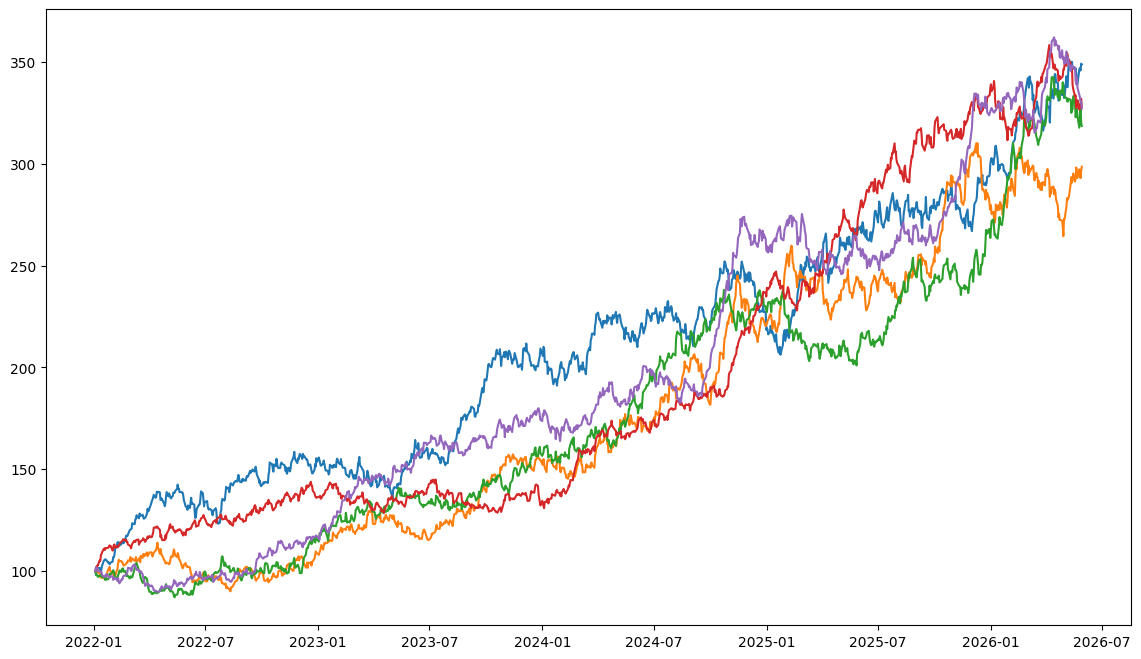

In [52]:
# Create Normalized NAV
plt.figure(figsize=(14,8))

for fund in top5_funds:

    temp = nav_history[
        nav_history['amfi_code'] == fund
    ].copy()

    temp = temp.sort_values('date')

    temp['normalized'] = (
        temp['nav']
        /
        temp['nav'].iloc[0]
    ) * 100

    plt.plot(
        temp['date'],
        temp['normalized'],
        label=f"Fund {fund}"
    )

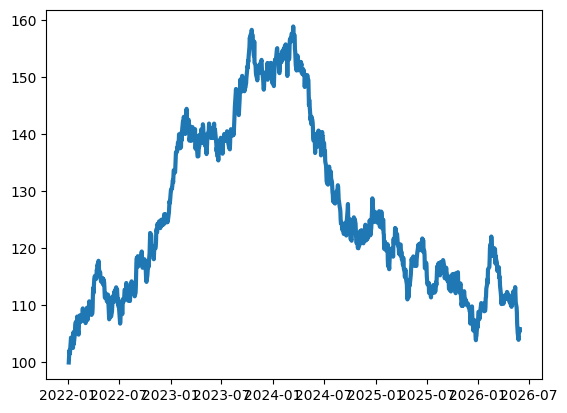

In [53]:
# Add NIFTY 50
n50 = benchmark[
    benchmark['index_name'] == 'NIFTY50'
].copy()

n50['normalized'] = (
    n50['close_value']
    /
    n50['close_value'].iloc[0]
) * 100

plt.plot(
    n50['date'],
    n50['normalized'],
    linewidth=3,
    label='NIFTY50'
)

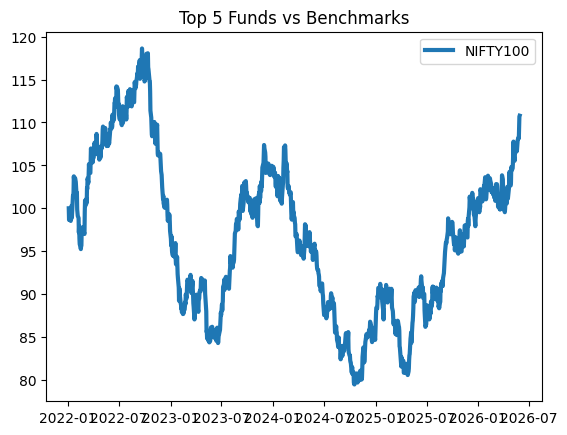

In [54]:
# Add NIFTY100
n100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

n100['normalized'] = (
    n100['close_value']
    /
    n100['close_value'].iloc[0]
) * 100

plt.plot(
    n100['date'],
    n100['normalized'],
    linewidth=3,
    label='NIFTY100'
)

plt.title(
    'Top 5 Funds vs Benchmarks'
)

plt.legend()

plt.savefig(
    r"D:\BlueStock FineTech\dashboard\charts\benchmark_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [62]:
scorecard.shape


(40, 12)

In [63]:
scorecard.head()

,amfi_code,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
4,120505,31.777537,1.180101,0.292636,1.36,-0.181885,0.900,0.900,0.950,0.650,0.625,84.50
0,119094,35.111802,0.998231,0.260767,1.38,-0.209609,1.000,0.750,0.800,0.600,0.700,80.75
3,100033,32.442459,1.093699,0.271954,1.38,-0.162172,0.925,0.850,0.875,0.600,0.500,80.50
1,148567,34.000916,1.448291,0.269838,1.46,-0.112657,0.975,1.000,0.850,0.450,0.200,80.00
6,120843,29.582770,1.306744,0.273305,1.45,-0.129740,0.850,0.975,0.900,0.475,0.325,78.25


# Tracking Error Calculation

In [64]:
tracking_error_results = []

for fund in top5_funds:

    fund_df = nav_history[
        nav_history['amfi_code'] == fund
    ][['date','daily_return']]

    merged = pd.merge(
        fund_df,
        nifty100[['date','benchmark_return']],
        on='date',
        how='inner'
    )

    merged = merged.dropna()

    tracking_error = (
        (merged['daily_return']
         -
         merged['benchmark_return']
        ).std()
    ) * np.sqrt(252)

    tracking_error_results.append([
        fund,
        tracking_error
    ])

tracking_error_df = pd.DataFrame(
    tracking_error_results,
    columns=[
        'amfi_code',
        'tracking_error'
    ]
)

tracking_error_df

,amfi_code,tracking_error
0,120505,0.231968
1,119094,0.237652
2,100033,0.228699
3,148567,0.189664
4,120843,0.206425


In [65]:
tracking_error_df.to_csv(
    r"D:\BlueStock FineTech\data\processed\tracking_error.csv",
    index=False
)